In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

from visualization import (
    bulk_vs_singlecell_matrix_viz,
    loop_heatmap_plots_real_data,
    super_plot_heatmaps_real_data,
    barplot_matches_nonmatches_na,
 )
from accuracy_functions import load_expected_matches_real_data, count_matches_real_data
from analysis_shared_functions import (
    load_heatmap_data,
    load_sample_matching_results,
    parse_sample_matching_results_vireo,
    matches_matrix_to_pair_df,
    parse_heatmap_matrix_hysys,
    create_pseudobulk_submatrix_vireo,
)

In [2]:
DATA_PATH = "../../data/output_data/" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

In [3]:
# Generally all the combinations of these parameters are present in the data, 
# except for BAMixChecker which only has results for read depth 0.
# And occassionally, tools may be missing results because they failed to run for certain combinations of parameters.
tools = ["CrosscheckFingerprints", "HYSYS", "NGSCheckmate", "Vireo"]
read_depths = [0, 1, 10, 20, 30, 40]
datasets = ["hgsoc", "hgsoc-new", "high_grade_glioma", "low_grade_glioma", "wilms_tumor"]

# Sample similarity heatmaps

Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 1...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 10...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 20...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 30...
Processing tool CrosscheckFingerprints, dataset low_grade_glioma, read depth 40...
Processing tool HYSYS, dataset low_grade_glioma, read depth 0...
Processing tool HYSYS, dataset low_grade_glioma, read depth 1...
Processing tool HYSYS, dataset low_grade_glioma, read depth 10...
Processing tool HYSYS, dataset low_grade_glioma, read depth 20...
Processing tool HYSYS, dataset low_grade_glioma, read depth 30...
Processing tool HYSYS, dataset low_grade_glioma, read depth 40...
Processing tool NGSCheckmate, dataset low_grade_glioma, read depth 0...
Processing tool NGSCheckmate, dataset 

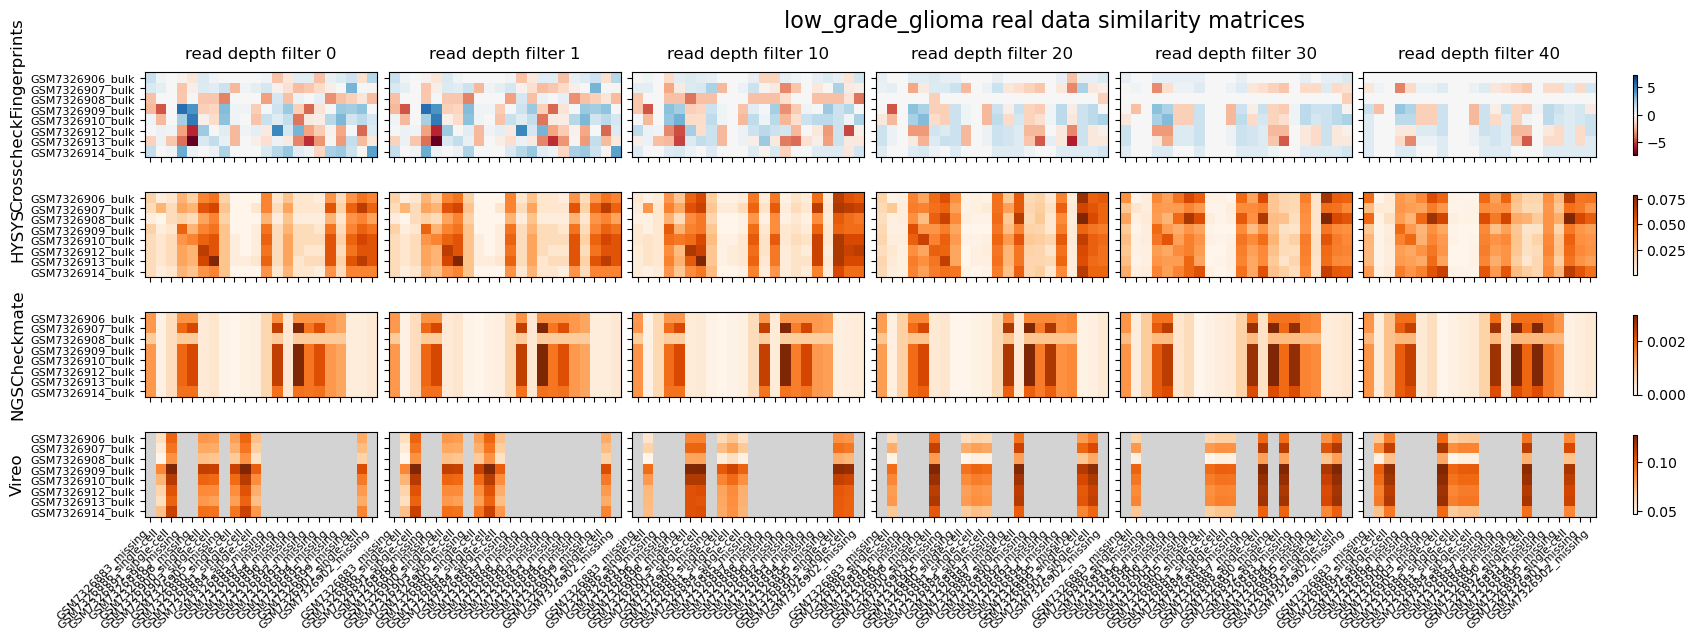

In [4]:
super_plot_heatmaps_real_data(
    DATA_PATH,
    FIGURES_PATH,
    tools,
    "low_grade_glioma",
    read_depths,
    mod1="bulk",
    mod2="single-cell",
    remove_missing_data=True,
    save_fig=True,
)

In [5]:
# bulk_vs_singlecell_matrix_viz(
#     DATA_PATH,
#     False,
#     "HYSYS",
#     "hgsoc-new",
#     "null",
#     0,
#     mod1="bulk_chunk_ribo",
#     mod2="bulk_diss_polyA",
#     save_fig=False,
#     FIGURES_PATH=FIGURES_PATH   ,
# )

In [6]:
# # The samples are ordered by expected matches, 
# # so that the diagonal should stand out if a tool is performing well.
# # This can be repeated for all the datasets and read depths listed above. 
# loop_heatmap_plots_real_data(
#     DATA_PATH,
#     FIGURES_PATH,
#     tools,
#     ["hgsoc-new"],
#     [0],
#     mod1="bulk_chunk_ribo",
#     mod2="bulk_diss_polyA",
# )

# Comparison of inferred and expected sample matches

Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 0...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 1...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 10...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 20...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 30...
Processing tool CrosscheckFingerprints, dataset high_grade_glioma, read depth 40...
Processing tool HYSYS, dataset high_grade_glioma, read depth 0...
Processing tool HYSYS, dataset high_grade_glioma, read depth 1...
Processing tool HYSYS, dataset high_grade_glioma, read depth 10...
Processing tool HYSYS, dataset high_grade_glioma, read depth 20...
Processing tool HYSYS, dataset high_grade_glioma, read depth 30...
Processing tool HYSYS, dataset high_grade_glioma, read depth 40...
Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...
Processing tool NGSCheckm

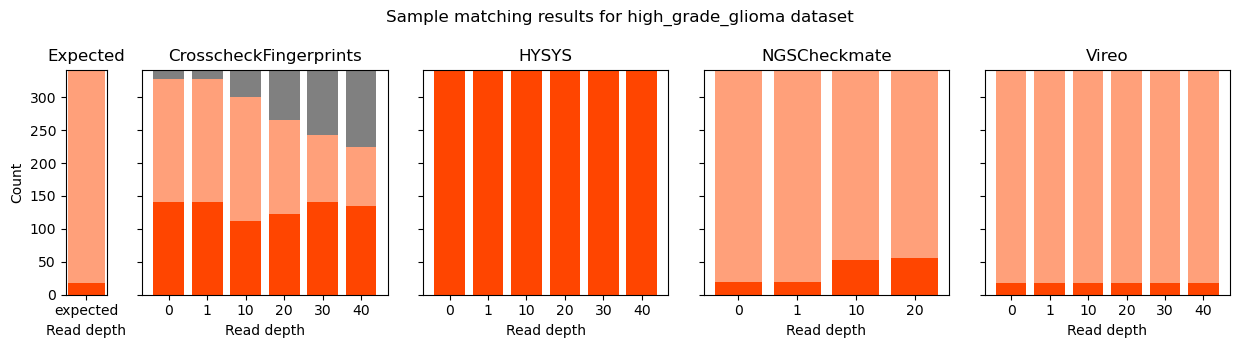

In [ ]:
# Convert a 0/1 sample-by-sample matrix into a dataframe of matched sample pairs
matrix_df = inferred_matches.copy()

# Ensure numeric 0/1 values
matrix_df = matrix_df.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

row_name = matrix_df.index.name or "sample_id_0"
col_name = matrix_df.columns.name or "sample_id_1"

# Keep coordinates where value == 1
matches_df = (
    matrix_df.eq(1)
    .stack()
    .loc[lambda s: s]
    .index.to_frame(index=False)
)
matches_df.columns = [row_name, col_name]

# If matrix is square with same sample labels on rows/cols, keep unique undirected pairs
if matrix_df.index.equals(matrix_df.columns):
    matches_df = matches_df[matches_df[row_name] < matches_df[col_name]].reset_index(drop=True)

matches_df
barplot_matches_nonmatches_na(DATA_PATH, tools, "high_grade_glioma", read_depths, "bulk", "single-cell", True, FIGURES_PATH)

In [18]:
def find_accuracy_mismatches(DATA_PATH, tool, dataset, read_depth, mod1="bulk", mod2="single-cell"):
    # Load expected matches
    expected_matches = load_expected_matches_real_data(DATA_PATH, dataset)

    # Load inferred matches
    inferred_matches = load_sample_matching_results(
        DATA_PATH,
        False,
        tool,
        dataset,
        "null",
        read_depth,
        mod1=mod1,
        mod2=mod2,
    )
    if inferred_matches is None:
        print(f"No inferred matches found for {tool} on {dataset} at read depth {read_depth}.")
        return None, None

    # Convert inferred matches matrix to pairwise dataframe
    matches_df = matches_matrix_to_pair_df(inferred_matches)

    # Split the sample IDs into their components (e.g., "sample1_bulk" -> "sample1", "bulk")
    matches_df[["sample_id_0", "modality_0"]] = matches_df["sample_id_0"].str.rsplit("_", n=1, expand=True)
    matches_df[["sample_id_1", "modality_1"]] = matches_df["sample_id_1"].str.rsplit("_", n=1, expand=True)

    # Merge with expected matches to determine which inferred matches are correct
    merged_df = expected_matches.merge(
        matches_df,
        right_on=["sample_id_0", "sample_id_1"],
        left_on=[mod1, mod2],
        how="outer",
        indicator="match_status"
    )

    # if tool == "Vireo":
    #     # Count number of mismatches
    #     num_nonmatches = (merged_df["match_status"] != "both").sum()
    #     # List the mismatches
    #     mismatches = merged_df[merged_df["match_status"] != "both"]
    # else:
    #     # Check whether the expected matches are present in the inferred matches
    #     expected_matches["expected_match"] = True
    #     merged_df = expected_matches.merge(
    #         merged_df,
    #         left_on=[mod1, mod2],
    #         right_on=["sample_id_0", "sample_id_1"],
    #         how="left",
    #         indicator="match_status"
    #     )

    return merged_df

In [19]:
# for rd in read_depths:
merged_df = find_accuracy_mismatches(DATA_PATH, "NGSCheckmate", "high_grade_glioma", 0, "bulk", "single-cell")
    # print(n_mismatches)
    # print(mismatches_df.iloc[:, :2])


Processing tool NGSCheckmate, dataset high_grade_glioma, read depth 0...


In [20]:
merged_df

,bulk,single-cell,sample_id_0,sample_id_1,modality_0,modality_1,match_status
0,GSM7305242,GSM7305260,GSM7305242,GSM7305260,bulk,single-cell,both
1,GSM7305243,GSM7305261,GSM7305243,GSM7305261,bulk,single-cell,both
2,GSM7305244,GSM7305262,GSM7305244,GSM7305262,bulk,single-cell,both
3,GSM7305245,GSM7305263,GSM7305245,GSM7305263,bulk,single-cell,both
4,GSM7305246,GSM7305264,NaN,NaN,NaN,NaN,left_only
5,NaN,NaN,GSM7305246,GSM7305268,bulk,single-cell,right_only
6,GSM7305247,GSM7305265,GSM7305247,GSM7305265,bulk,single-cell,both
7,GSM7305248,GSM7305266,GSM7305248,GSM7305266,bulk,single-cell,both
8,GSM7305249,GSM7305267,GSM7305249,GSM7305267,bulk,single-cell,both
9,GSM7305250,GSM7305268,NaN,NaN,NaN,NaN,left_only


In [60]:
_, hysys_matrix = parse_heatmap_matrix_hysys(DATA_PATH, False, "high_grade_glioma", "null", 0)

In [61]:
mod1 = "bulk"
mod2 = "single-cell"
mod1_samples = [idx for idx in hysys_matrix.index if mod1 in idx]
mod2_samples = [col for col in hysys_matrix.columns if mod2 in col]
hysys_matrix = hysys_matrix.loc[mod1_samples, mod2_samples]


In [62]:
hysys_matrix

,GSM7305260_single-cell,GSM7305261_single-cell,GSM7305262_single-cell,GSM7305263_single-cell,GSM7305264_single-cell,GSM7305265_single-cell,GSM7305266_single-cell,GSM7305267_single-cell,GSM7305268_single-cell,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
0,,,,,,,,,,,,,,,,,,,
GSM7305242_bulk,0.015,0.013,0.003,0.011,0.009,0.004,0.008,0.003,0.002,0.007,0.003,0.004,0.006,0.004,0.004,0.010,0.007,0.013,0.008
GSM7305243_bulk,0.010,0.026,0.004,0.013,0.009,0.005,0.008,0.004,0.003,0.008,0.004,0.005,0.008,0.004,0.005,0.011,0.006,0.015,0.008
GSM7305244_bulk,0.011,0.011,0.004,0.010,0.009,0.003,0.009,0.003,0.002,0.007,0.003,0.004,0.006,0.004,0.003,0.010,0.008,0.012,0.008
GSM7305245_bulk,0.010,0.010,0.002,0.015,0.009,0.003,0.009,0.002,0.001,0.006,0.002,0.003,0.005,0.003,0.002,0.010,0.007,0.011,0.007
GSM7305246_bulk,0.012,0.013,0.003,0.011,0.014,0.004,0.010,0.003,0.002,0.007,0.003,0.004,0.006,0.003,0.004,0.011,0.008,0.015,0.009
GSM7305247_bulk,0.013,0.013,0.003,0.011,0.010,0.005,0.010,0.003,0.002,0.006,0.003,0.003,0.006,0.003,0.003,0.011,0.008,0.014,0.008
GSM7305248_bulk,0.010,0.010,0.002,0.009,0.008,0.003,0.014,0.002,0.001,0.005,0.002,0.003,0.005,0.003,0.003,0.010,0.007,0.012,0.007
GSM7305249_bulk,0.011,0.013,0.003,0.011,0.009,0.004,0.009,0.005,0.002,0.007,0.003,0.004,0.006,0.003,0.003,0.010,0.008,0.014,0.008
GSM7305250_bulk,0.011,0.013,0.003,0.010,0.009,0.004,0.009,0.003,0.003,0.006,0.003,0.003,0.006,0.003,0.004,0.011,0.008,0.013,0.008


In [63]:
idx0, idx1 = linear_sum_assignment(hysys_matrix.values, True)
matrix_reordered = pd.DataFrame(
    hysys_matrix.iloc[idx0, idx1],
    index=hysys_matrix.index[idx0],
    columns=hysys_matrix.columns[idx1],
)

In [64]:
# If there are more columns than rows (double samples),
# we need to add back the unmatched columns (these were inferred as non-matches)
if len(hysys_matrix.columns) > len(hysys_matrix.index):
    unmatched_cols = [
        col for col in mod2_samples if col not in matrix_reordered.columns
    ]
    for col in unmatched_cols:
        matrix_reordered[col] = 0
# If there are more rows than columns (missing samples),
# we need to add back the unmatched rows (these were inferred as non-matches)
elif len(hysys_matrix.index) > len(hysys_matrix.columns):
    unmatched_rows = [idx for idx in mod1_samples if idx not in matrix_reordered.index]
    for idx in unmatched_rows:
        matrix_reordered.loc[idx] = 0

In [65]:
matrix_reordered.shape

(18, 19)

In [66]:
hysys_matrix.shape

(18, 19)

In [67]:
import itertools 
padded_lists = itertools.zip_longest(matrix_reordered.index, matrix_reordered.columns, fillvalue=np.nan)
mod1_samples, mod2_samples = zip(*padded_lists)

hysys_vireo_df = pd.DataFrame(
    {
        f"{mod1}": mod1_samples, 
        f"{mod2}": mod2_samples
    }
)

In [68]:
# Split the sample IDs into their components (e.g., "sample1_bulk" -> "sample1", "bulk")
hysys_vireo_df[["sample_id_0", "modality_0"]] = hysys_vireo_df[f"{mod1}"].str.rsplit("_", n=1, expand=True)
hysys_vireo_df[["sample_id_1", "modality_1"]] = hysys_vireo_df[f"{mod2}"].str.rsplit("_", n=1, expand=True)

expected_matches = load_expected_matches_real_data(DATA_PATH, "high_grade_glioma")

# Merge with expected matches to determine which inferred matches are correct
merged_df = expected_matches.merge(
    hysys_vireo_df,
    right_on=["sample_id_0", "sample_id_1"],
    left_on=[mod1, mod2],
    how="outer",
    indicator="match_status"
)

In [69]:
merged_df

,bulk_x,single-cell_x,bulk_y,single-cell_y,sample_id_0,modality_0,sample_id_1,modality_1,match_status
0,GSM7305242,GSM7305260,GSM7305242_bulk,GSM7305260_single-cell,GSM7305242,bulk,GSM7305260,single-cell,both
1,GSM7305243,GSM7305261,GSM7305243_bulk,GSM7305261_single-cell,GSM7305243,bulk,GSM7305261,single-cell,both
2,GSM7305244,GSM7305262,GSM7305244_bulk,GSM7305262_single-cell,GSM7305244,bulk,GSM7305262,single-cell,both
3,GSM7305245,GSM7305263,GSM7305245_bulk,GSM7305263_single-cell,GSM7305245,bulk,GSM7305263,single-cell,both
4,GSM7305246,GSM7305264,GSM7305246_bulk,GSM7305264_single-cell,GSM7305246,bulk,GSM7305264,single-cell,both
5,GSM7305247,GSM7305265,GSM7305247_bulk,GSM7305265_single-cell,GSM7305247,bulk,GSM7305265,single-cell,both
6,GSM7305248,GSM7305266,GSM7305248_bulk,GSM7305266_single-cell,GSM7305248,bulk,GSM7305266,single-cell,both
7,GSM7305249,GSM7305267,GSM7305249_bulk,GSM7305267_single-cell,GSM7305249,bulk,GSM7305267,single-cell,both
8,GSM7305250,GSM7305268,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,NaN,NaN,GSM7305250_bulk,GSM7305277_single-cell,GSM7305250,bulk,GSM7305277,single-cell,right_only
